In [1]:
import torch
import numpy as np
import sys
import omnilearned
sys.path.append("/home/yfkahn/projects/aip-yfkahn/shared/jet_interpretability_diffusion/GenerativeModelsOnPhaseSpace-main")
from omnilearn_lightning import qspace
import matplotlib.pyplot as plt

In [21]:
qhead="forward_backward_outputs/N10_T5000_ee2qqbar_S2000GeV_a0p1365_tgaus0_qspace_roundtrip_T"
phats = []
ts_forward = [50, 150, 200,250,400,600,800, 1000, 1200]
for i in ts_forward:
    qhats = torch.load(qhead+str(i)+".pt")
    ps_temp = torch.zeros(qhats.shape)
    for j in range(ps_temp.shape[0]):
        ps_temp[j]=qspace.qs_to_ps(qhats[j])
    phats.append(ps_temp) #shape (checkpoints, trajectories, samples, particles, 3-momentum)

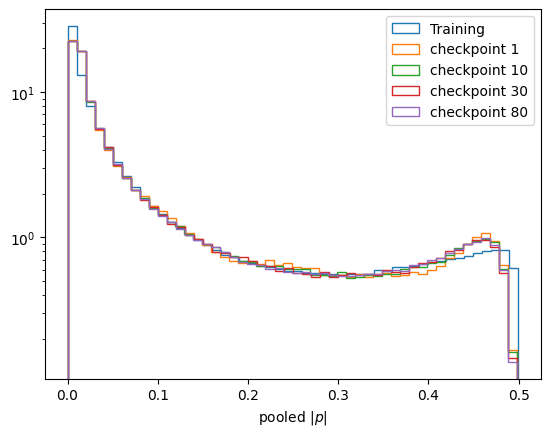

In [22]:
#all of these distributions are fully denoised, and so should look like the training data
pspace_dat = torch.load("/home/yfkahn/projects/aip-yfkahn/shared/intermediate_by_nbranch/ee2qqbar/ee2qqbar_S=2000GeV_a=0p1365_N=2000000_NBranch=8_Nparticles=10_p3_normalized.pt")
plt.hist(pspace_dat[:100000].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label='Training')
plt.hist(phats[0].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label="checkpoint 1")
plt.hist(phats[1].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label="checkpoint 10")
plt.hist(phats[2].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label="checkpoint 30")
plt.hist(phats[3].norm(dim=-1).flatten(),bins=50,histtype='step',density=True,label="checkpoint 80")
plt.yscale('log')
plt.xlabel(r'pooled $|p|$')
plt.legend()


In [23]:
def compute_momentum_susceptibility(p0,phat,norm=True): #computes at fixed time: phats is a (Ntraj,Nsample,Nparticles,3) array
    Ntraj=phat.shape[0]
    Nsample=phat.shape[1]
    DeltaPs = p0[None,:Nsample,...]-phat
    pnorms=DeltaPs.norm(dim=-1)
    Cij_trajavg=(1/pnorms.shape[0])*torch.einsum('tnp,tnq->npq',pnorms,pnorms)- torch.einsum('np,nq->npq',pnorms.mean(dim=0),pnorms.mean(dim=0))
    Cij=Cij_trajavg.mean(dim=0)
    if norm:
        chi=torch.sum(Cij)/torch.sum(Cij.diag())
    else:
        chi=torch.sum(Cij)
    return chi

In [24]:
chis_norm=[]
chis_unnorm=[]
for i in range(len(ts_forward)):
    chi = compute_momentum_susceptibility(pspace_dat,phats[i])
    chis_norm.append(chi)
    chi = compute_momentum_susceptibility(pspace_dat,phats[i],norm=False)
    chis_unnorm.append(chi)

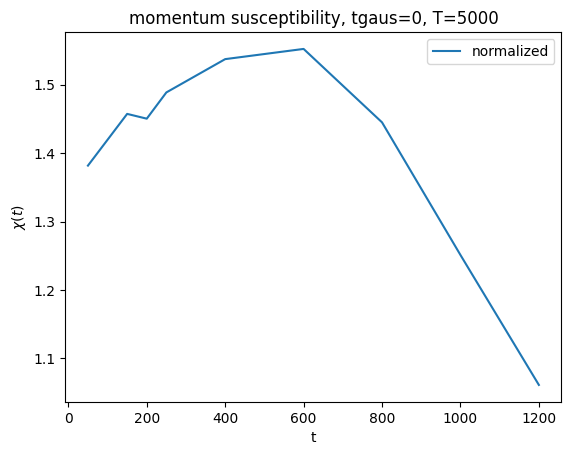

In [25]:
plt.plot(ts_forward,chis_norm,label='normalized')
#plt.plot(ts_forward,30*np.array(chis_unnorm),label='un-normalized (rescaled)')
plt.title('momentum susceptibility, tgaus=0, T=5000')
plt.xlabel('t')
plt.ylabel(r'$\chi(t)$')
plt.legend(loc='upper right')